# Xception Deepfake Detector — Colab Training

**Before running:**
1. Runtime → Change runtime type → **T4 GPU** (or A100 if on Pro)
2. Upload `dataset.zip` to your Google Drive
3. Update `DATASET_ZIP` in Cell 2 if your zip is not at `MyDrive/dataset.zip`
4. Run all cells top to bottom

Checkpoints are saved back to Drive so they survive session disconnects.

In [ ]:
# ── Cell 1: GPU check + dependencies ────────────────────────────
import torch

if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. Go to Runtime → Change runtime type → GPU.")

name   = torch.cuda.get_device_name(0)
mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU  : {name}")
print(f"VRAM : {mem_gb:.1f} GB")
print(f"Torch: {torch.__version__}")

# All other deps (scikit-learn, tqdm, torchvision) are pre-installed on Colab
# Uncomment if any are missing:
# !pip install -q scikit-learn tqdm torchvision

GPU  : Tesla T4
VRAM : 15.6 GB
Torch: 2.10.0+cu128


In [ ]:
# ── Cell 2: Mount Drive + unzip dataset ─────────────────────────
import os, zipfile, shutil
from google.colab import drive

drive.mount('/content/drive')

DATASET_ZIP = '/content/drive/MyDrive/dataset.zip'   # adjust if stored elsewhere
MODELS_DIR  = '/content/drive/MyDrive/deepfake-models'

os.makedirs(MODELS_DIR, exist_ok=True)

# ── Extract ──────────────────────────────────────────────────────
EXTRACT_ROOT = '/content/extracted'

if not os.path.exists(EXTRACT_ROOT):
    LOCAL_ZIP = '/content/dataset.zip'
    if not os.path.exists(LOCAL_ZIP):
        print("Copying zip from Drive to local disk ...")
        shutil.copy2(DATASET_ZIP, LOCAL_ZIP)
        print("Copy done.")
    print("Unzipping ...")
    with zipfile.ZipFile(LOCAL_ZIP, 'r') as z:
        z.extractall(EXTRACT_ROOT)
    os.remove(LOCAL_ZIP)
    print("Done.")
else:
    print("Already extracted — skipping.")

# ── Auto-detect dataset root ─────────────────────────────────────
# Walk the extraction to find the folder containing train/ val/ test/
def find_dataset_root(base):
    for root, dirs, _ in os.walk(base):
        if {'train', 'val', 'test'}.issubset(set(dirs)):
            return root
    return None

DATASET_DIR = find_dataset_root(EXTRACT_ROOT)

if DATASET_DIR is None:
    # Show what actually extracted so the user can diagnose
    print("\nCould not find train/val/test. Extracted structure:")
    for root, dirs, files in os.walk(EXTRACT_ROOT):
        depth = root.replace(EXTRACT_ROOT, '').count(os.sep)
        if depth < 3:
            indent = '  ' * depth
            print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")
    raise RuntimeError("Dataset root not found — check printed structure above.")

print(f"Dataset root: {DATASET_DIR}")

# Sanity check
for split in ['train', 'val', 'test']:
    for label in ['real', 'fake']:
        d = os.path.join(DATASET_DIR, split, label)
        n = len(os.listdir(d)) if os.path.exists(d) else 0
        print(f"  {split}/{label}: {n:,} frames")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying zip from Drive to local disk ...
Copy done.
Unzipping ...
Done.
Dataset root: /content/extracted
  train/real: 10,485 frames
  train/fake: 62,906 frames
  val/real: 2,250 frames
  val/fake: 13,500 frames
  test/real: 2,265 frames
  test/fake: 13,578 frames


In [ ]:
# ── Cell 3: Xception model ───────────────────────────────────────
import torch
import torch.nn as nn


class SeparableConv2d(nn.Module):
    """Depthwise separable convolution: depthwise → pointwise → BN → optional ReLU."""

    def __init__(self, in_channels, out_channels, kernel_size=3,
                 stride=1, padding=1, bias=False, activate_first=True):
        super().__init__()
        self.activate_first = activate_first
        self.relu      = nn.ReLU()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size,
                                   stride=stride, padding=padding, groups=in_channels, bias=bias)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=bias)
        self.bn        = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        if self.activate_first:
            x = self.relu(x)
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return x


class EntryFlowBlock(nn.Module):
    """Two SeparableConvs + MaxPool + 1x1 skip. Halves spatial dims."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.sep_convs = nn.Sequential(
            SeparableConv2d(in_channels,  out_channels, activate_first=True),
            SeparableConv2d(out_channels, out_channels, activate_first=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.sep_convs(x) + self.skip(x)


class MiddleFlowBlock(nn.Module):
    """Three SeparableConvs + residual, no downsampling. Repeated 8x."""

    def __init__(self, channels=728):
        super().__init__()
        self.sep_convs = nn.Sequential(
            SeparableConv2d(channels, channels, activate_first=True),
            SeparableConv2d(channels, channels, activate_first=True),
            SeparableConv2d(channels, channels, activate_first=True),
        )

    def forward(self, x):
        return self.sep_convs(x) + x


class ExitFlowBlock(nn.Module):
    """728→1024 with MaxPool + 1x1 skip. Halves spatial dims."""

    def __init__(self):
        super().__init__()
        self.sep_convs = nn.Sequential(
            SeparableConv2d(728,  728,  activate_first=True),
            SeparableConv2d(728,  1024, activate_first=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(728, 1024, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(1024),
        )

    def forward(self, x):
        return self.sep_convs(x) + self.skip(x)


class Xception(nn.Module):
    """Xception for binary deepfake detection. Input: (B,3,224,224) → Output: (B,2)"""

    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.entry_stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
        )
        self.entry_block1 = EntryFlowBlock(64,  128)
        self.entry_block2 = EntryFlowBlock(128, 256)
        self.entry_block3 = EntryFlowBlock(256, 728)
        self.middle_flow  = nn.Sequential(*[MiddleFlowBlock(728) for _ in range(8)])
        self.exit_block   = ExitFlowBlock()
        self.exit_sep1    = SeparableConv2d(1024, 1536, activate_first=False)
        self.exit_sep2    = SeparableConv2d(1536, 2048, activate_first=False)
        self.exit_relu    = nn.ReLU()
        self.gap          = nn.AdaptiveAvgPool2d(1)
        self.classifier   = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(2048, num_classes))
        self._init_weights()

    def forward(self, x):
        x = self.entry_stem(x)
        x = self.entry_block1(x)
        x = self.entry_block2(x)
        x = self.entry_block3(x)
        x = self.middle_flow(x)
        x = self.exit_block(x)
        x = self.exit_sep1(x)
        x = self.exit_sep2(x)
        x = self.exit_relu(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)


model = Xception().cuda()
total = sum(p.numel() for p in model.parameters())
print(f"Xception loaded — {total:,} parameters")

# Shape check
with torch.no_grad():
    out = model(torch.randn(2, 3, 224, 224).cuda())
print(f"Output shape: {tuple(out.shape)}  (expect (2, 2))")

Xception loaded — 20,811,050 parameters
Output shape: (2, 2)  (expect (2, 2))


In [ ]:
# ── Cell 4: Dataloaders ──────────────────────────────────────────
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
from pathlib import Path

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomRotation(degrees=10, interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

data_dir      = Path(DATASET_DIR)
train_dataset = ImageFolder(data_dir / 'train', transform=train_transforms)
val_dataset   = ImageFolder(data_dir / 'val',   transform=eval_transforms)
test_dataset  = ImageFolder(data_dir / 'test',  transform=eval_transforms)

# Class weights for imbalanced 85/15 fake/real split
counts        = Counter(train_dataset.targets)
n_total       = len(train_dataset)
class_weights = torch.zeros(2)
for idx, count in counts.items():
    class_weights[idx] = n_total / (2 * count)

sample_weights = torch.tensor([class_weights[l] for l in train_dataset.targets])
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

BATCH_SIZE   = 64   # T4/A100 can handle 64 at 224x224; drop to 32 if OOM
NUM_WORKERS  = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train : {len(train_dataset):,} samples")
print(f"Val   : {len(val_dataset):,} samples")
print(f"Test  : {len(test_dataset):,} samples")
print(f"Class weights — fake: {class_weights[0]:.4f}  real: {class_weights[1]:.4f}")
print(f"Batch size: {BATCH_SIZE}")

Train : 73,391 samples
Val   : 15,750 samples
Test  : 15,843 samples
Class weights — fake: 0.5833  real: 3.4998
Batch size: 64


In [ ]:
# ── Cell 5: Training setup ───────────────────────────────────────
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

LEARNING_RATE   = 1e-4
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.1
GRAD_CLIP_NORM  = 1.0
NUM_EPOCHS      = 30
COSINE_T0       = 10
COSINE_T_MULT   = 2
EARLY_STOP_PAT  = 7

RESUME_PATH = f'{MODELS_DIR}/xception_best.pth'  # resumes automatically if it exists

criterion = nn.CrossEntropyLoss(
    weight=class_weights.cuda(), label_smoothing=LABEL_SMOOTHING
)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=COSINE_T0, T_mult=COSINE_T_MULT)
scaler    = torch.amp.GradScaler('cuda')

start_epoch   = 0
best_val_loss = float('inf')

if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, map_location='cuda')
    model.load_state_dict(ckpt['model_state_dict'])
    start_epoch   = ckpt.get('epoch', 0) + 1
    best_val_loss = ckpt.get('val_loss', float('inf'))
    print(f"Resumed from epoch {start_epoch}  (best val_loss={best_val_loss:.4f})")
else:
    print("Starting from scratch.")

print(f"Training for epochs {start_epoch+1} → {NUM_EPOCHS}")

Starting from scratch.
Training for epochs 1 → 30


In [ ]:
# ── Cell 6: Train ────────────────────────────────────────────────
import time, csv
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm

LOG_PATH = f'{MODELS_DIR}/xception_training_log.csv'


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  train', leave=False):
        images, labels = images.cuda(), labels.cuda()
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, split='val'):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for images, labels in tqdm(loader, desc=f'  {split}', leave=False):
        images, labels = images.cuda(), labels.cuda()
        outputs        = model(images)
        loss           = criterion(outputs, labels)
        running_loss  += loss.item() * images.size(0)
        correct       += (outputs.argmax(1) == labels).sum().item()
        total         += labels.size(0)
        all_probs.extend(torch.softmax(outputs, 1)[:, 0].cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')
    return {'loss': running_loss / total, 'accuracy': correct / total, 'auc': auc}


no_improve  = 0
val_metrics = {}
write_header = not os.path.exists(LOG_PATH)

print('=' * 60)
print(f'Training Xception  |  epochs {start_epoch+1}→{NUM_EPOCHS}  |  batch={BATCH_SIZE}')
print('=' * 60)

for epoch in range(start_epoch, NUM_EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    val_metrics           = evaluate(model, val_loader, criterion)
    elapsed               = time.time() - t0
    lr                    = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch+1:>3}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | "
        f"val_loss={val_metrics['loss']:.4f}  "
        f"val_acc={val_metrics['accuracy']:.4f}  "
        f"val_auc={val_metrics['auc']:.4f} | "
        f"lr={lr:.2e}  ({elapsed:.0f}s)"
    )

    row = {
        'epoch': epoch+1, 'train_loss': round(train_loss, 6),
        'train_acc': round(train_acc, 6), 'val_loss': round(val_metrics['loss'], 6),
        'val_acc': round(val_metrics['accuracy'], 6), 'val_auc': round(val_metrics['auc'], 6),
        'lr': lr, 'elapsed_s': round(elapsed, 1),
    }
    with open(LOG_PATH, 'w' if write_header else 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if write_header: w.writeheader()
        w.writerow(row)
    write_header = False

    scheduler.step(epoch + 1)

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        no_improve    = 0
        torch.save(
            {'model_state_dict': model.state_dict(), 'epoch': epoch,
             'val_loss': best_val_loss, 'val_auc': val_metrics['auc']},
            RESUME_PATH,
        )
        print(f'  New best saved → {RESUME_PATH}  (val_loss={best_val_loss:.4f})')
    else:
        no_improve += 1

    if no_improve >= EARLY_STOP_PAT:
        print(f'\nEarly stopping — no improvement for {EARLY_STOP_PAT} epochs.')
        break

# Save final weights
torch.save(
    {'model_state_dict': model.state_dict(), 'epoch': NUM_EPOCHS,
     'val_loss': val_metrics.get('loss', 0)},
    f'{MODELS_DIR}/xception_final.pth',
)
print('\nTraining complete.')
print(f'  Checkpoints : {MODELS_DIR}')
print(f'  Training log: {LOG_PATH}')

Training Xception  |  epochs 1→30  |  batch=64


  train:   0%|          | 0/1146 [00:00<?, ?it/s]

  val:   0%|          | 0/247 [00:00<?, ?it/s]

Epoch   1/30 | train_loss=0.4256  train_acc=0.5382 | val_loss=1.8253  val_acc=0.2654  val_auc=0.4082 | lr=1.00e-04  (796s)
  New best saved → /content/drive/MyDrive/deepfake-models/xception_best.pth  (val_loss=1.8253)


  train:   0%|          | 0/1146 [00:00<?, ?it/s]

...

  val:   0%|          | 0/247 [00:00<?, ?it/s]

Epoch  11/30 | train_loss=0.3521  train_acc=0.6253 | val_loss=1.5315  val_acc=0.3753  val_auc=0.2921 | lr=1.00e-04  (766s)


  train:   0%|          | 0/1146 [00:00<?, ?it/s]

  val:   0%|          | 0/247 [00:00<?, ?it/s]

Epoch  12/30 | train_loss=0.3438  train_acc=0.6425 | val_loss=1.9695  val_acc=0.3133  val_auc=0.2927 | lr=9.94e-05  (763s)

Early stopping — no improvement for 7 epochs.

Training complete.
  Checkpoints : /content/drive/MyDrive/deepfake-models
  Training log: /content/drive/MyDrive/deepfake-models/xception_training_log.csv


In [ ]:
!pip install torch

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded checkpoint  (epoch 5, val_loss=1.3823)



testing:   0%|          | 0/248 [00:00<?, ?it/s]

  Metric                  Value
  ------------------------------
  Accuracy               0.3194
  Precision  (fake)      0.9868
  Recall     (fake)      0.2087
  F1-score   (fake)      0.3446
  AUC-ROC                0.3132
  Avg Precision          0.0966

Full per-class breakdown:
              precision    recall  f1-score   support

        fake       0.99      0.21      0.34     13578
        real       0.17      0.98      0.29      2265

    accuracy                           0.32     15843
   macro avg       0.58      0.60      0.32     15843
weighted avg       0.87      0.32      0.34     15843



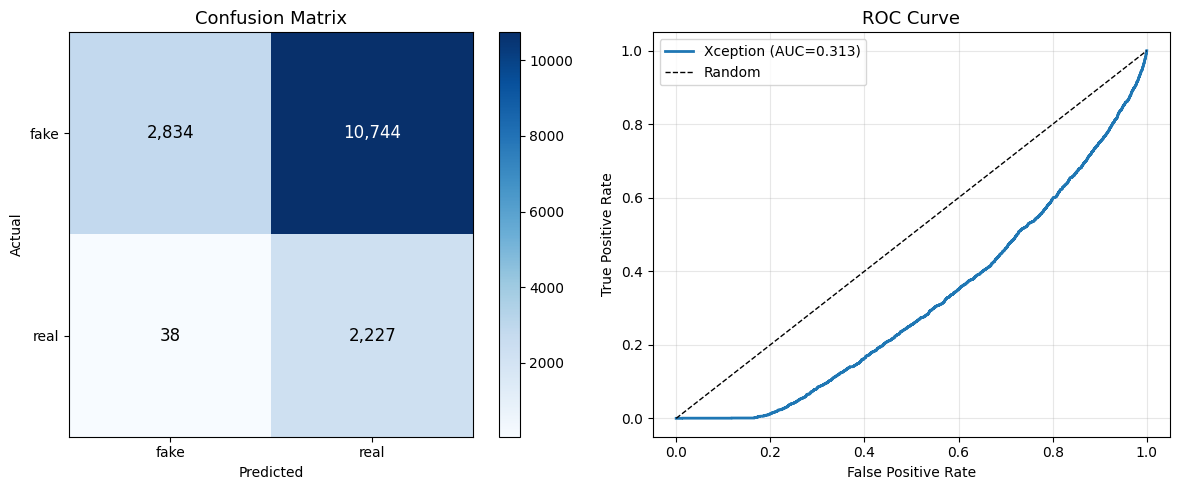

Saved → /content/drive/MyDrive/deepfake-models/xception_evaluation.png


In [ ]:
# ── Cell 7: Test metrics — accuracy, precision, recall, F-score ──
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score,
)
from tqdm.notebook import tqdm

drive.mount('/content/drive')
MODELS_DIR  = '/content/drive/MyDrive/deepfake-models'
RESUME_PATH = f'{MODELS_DIR}/xception_best.pth'

# ── Load best checkpoint ─────────────────────────────────────────
best_ckpt = torch.load(RESUME_PATH, map_location='cuda', weights_only=False)
model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()
print(f"Loaded checkpoint  (epoch {best_ckpt['epoch']+1}, val_loss={best_ckpt['val_loss']:.4f})\n")

# ── Collect predictions on test set ─────────────────────────────
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='testing'):
        outputs = model(images.cuda())
        probs   = torch.softmax(outputs, dim=1)[:, 0].cpu().numpy()  # P(fake)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# class_to_idx: {'fake': 0, 'real': 1}
class_names = ['fake', 'real']

# ── Metrics (fake = positive class) ─────────────────────────────
accuracy  = accuracy_score( all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary', pos_label=0)
recall    = recall_score(   all_labels, all_preds, average='binary', pos_label=0)
f1        = f1_score(       all_labels, all_preds, average='binary', pos_label=0)
auc       = roc_auc_score(all_labels, all_probs)
avg_prec  = average_precision_score(all_labels, all_probs)

print(f"{'='*45}")
print(f"  {'Metric':<20} {'Value':>8}")
print(f"  {'-'*30}")
print(f"  {'Accuracy':<20} {accuracy:>8.4f}")
print(f"  {'Precision  (fake)':<20} {precision:>8.4f}")
print(f"  {'Recall     (fake)':<20} {recall:>8.4f}")
print(f"  {'F1-score   (fake)':<20} {f1:>8.4f}")
print(f"  {'AUC-ROC':<20} {auc:>8.4f}")
print(f"  {'Avg Precision':<20} {avg_prec:>8.4f}")
print(f"{'='*45}")
print("\nFull per-class breakdown:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ── Confusion matrix + ROC curve ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_labels, all_preds)
im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(class_names)
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(class_names)
plt.colorbar(im, ax=axes[0])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, lw=2, label=f'Xception (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/xception_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {MODELS_DIR}/xception_evaluation.png")